# Analyse Exploratoire des Données (EDA) - Telco Customer Churn
Ce notebook présente une analyse approfondie des facteurs influençant le churn des clients.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Configuration du style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Chargement des données
df = pd.read_csv('dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Nettoyage initial
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Analyse de la cible (Churn)
Nous commençons par visualiser le déséquilibre des classes et calculer le taux de churn de référence.

Taux de Churn de référence : 26.54%


/var/folders/_m/sptr_0490fqbhk5rx47f__9w0000gn/T/ipykernel_66777/2018569466.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')


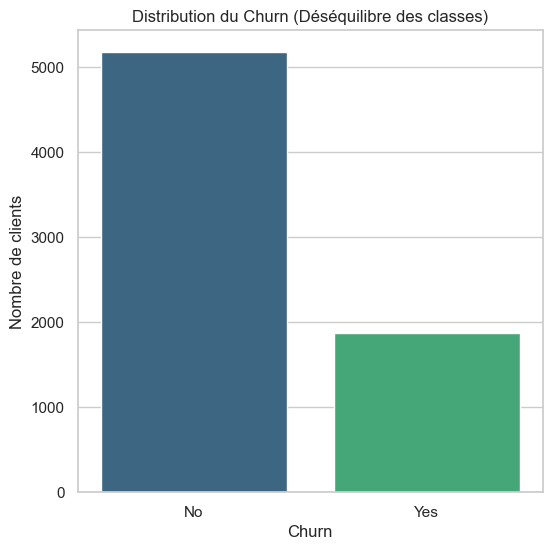

In [2]:
churn_counts = df['Churn'].value_counts(normalize=True) * 100
print(f"Taux de Churn de référence : {churn_counts['Yes']:.2f}%")

plt.figure(figsize=(6, 6))
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Distribution du Churn (Déséquilibre des classes)')
plt.ylabel('Nombre de clients')
plt.show()

**Interprétation Business :** Le dataset présente un déséquilibre significatif avec environ 26.5% de churn. Un modèle de base prédisant toujours 'No' aurait une précision de ~73%, ce qui souligne l'importance d'utiliser des métriques comme le Recall ou le F1-Score.

## 2. Analyse de la 'Stickiness' (Adhérence)
### Relation entre Tenure (Ancienneté) et Churn

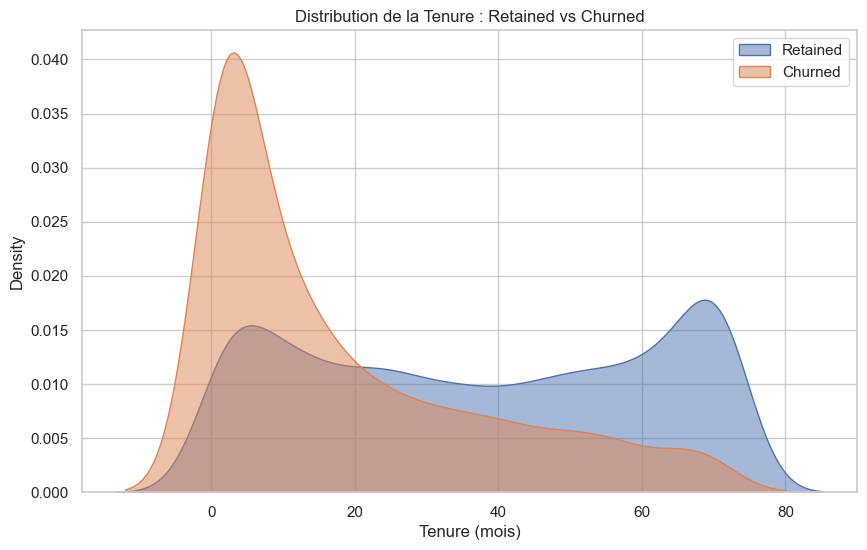

In [3]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['Churn'] == 'No'], x='tenure', label='Retained', fill=True, alpha=0.5)
sns.kdeplot(data=df[df['Churn'] == 'Yes'], x='tenure', label='Churned', fill=True, alpha=0.5)
plt.title('Distribution de la Tenure : Retained vs Churned')
plt.xlabel('Tenure (mois)')
plt.legend()
plt.show()

**Interprétation Business :** On observe un pic massif de churn durant les premiers mois de contrat (tenure < 10). Les clients qui dépassent les 20 mois ont une probabilité beaucoup plus élevée de rester fidèles. Les stratégies de rétention doivent se concentrer sur l'onboarding.

### Impact du Type de Contrat

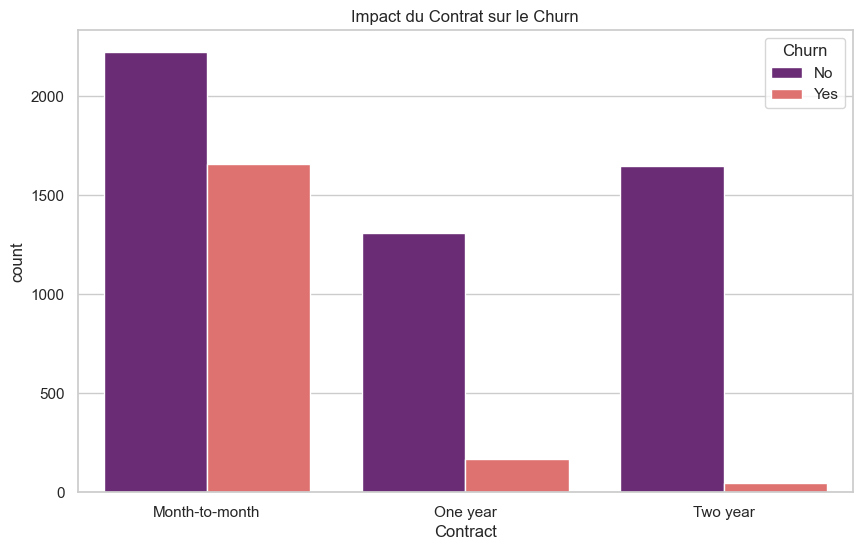

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Contract', hue='Churn', palette='magma')
plt.title('Impact du Contrat sur le Churn')
plt.show()

**Interprétation Business :** Le contrat 'Month-to-month' est le levier de risque majeur. La quasi-totalité du churn provient de cette catégorie. Les contrats à long terme (1 ou 2 ans) agissent comme une barrière naturelle au départ.

## 3. Segmentation des Services

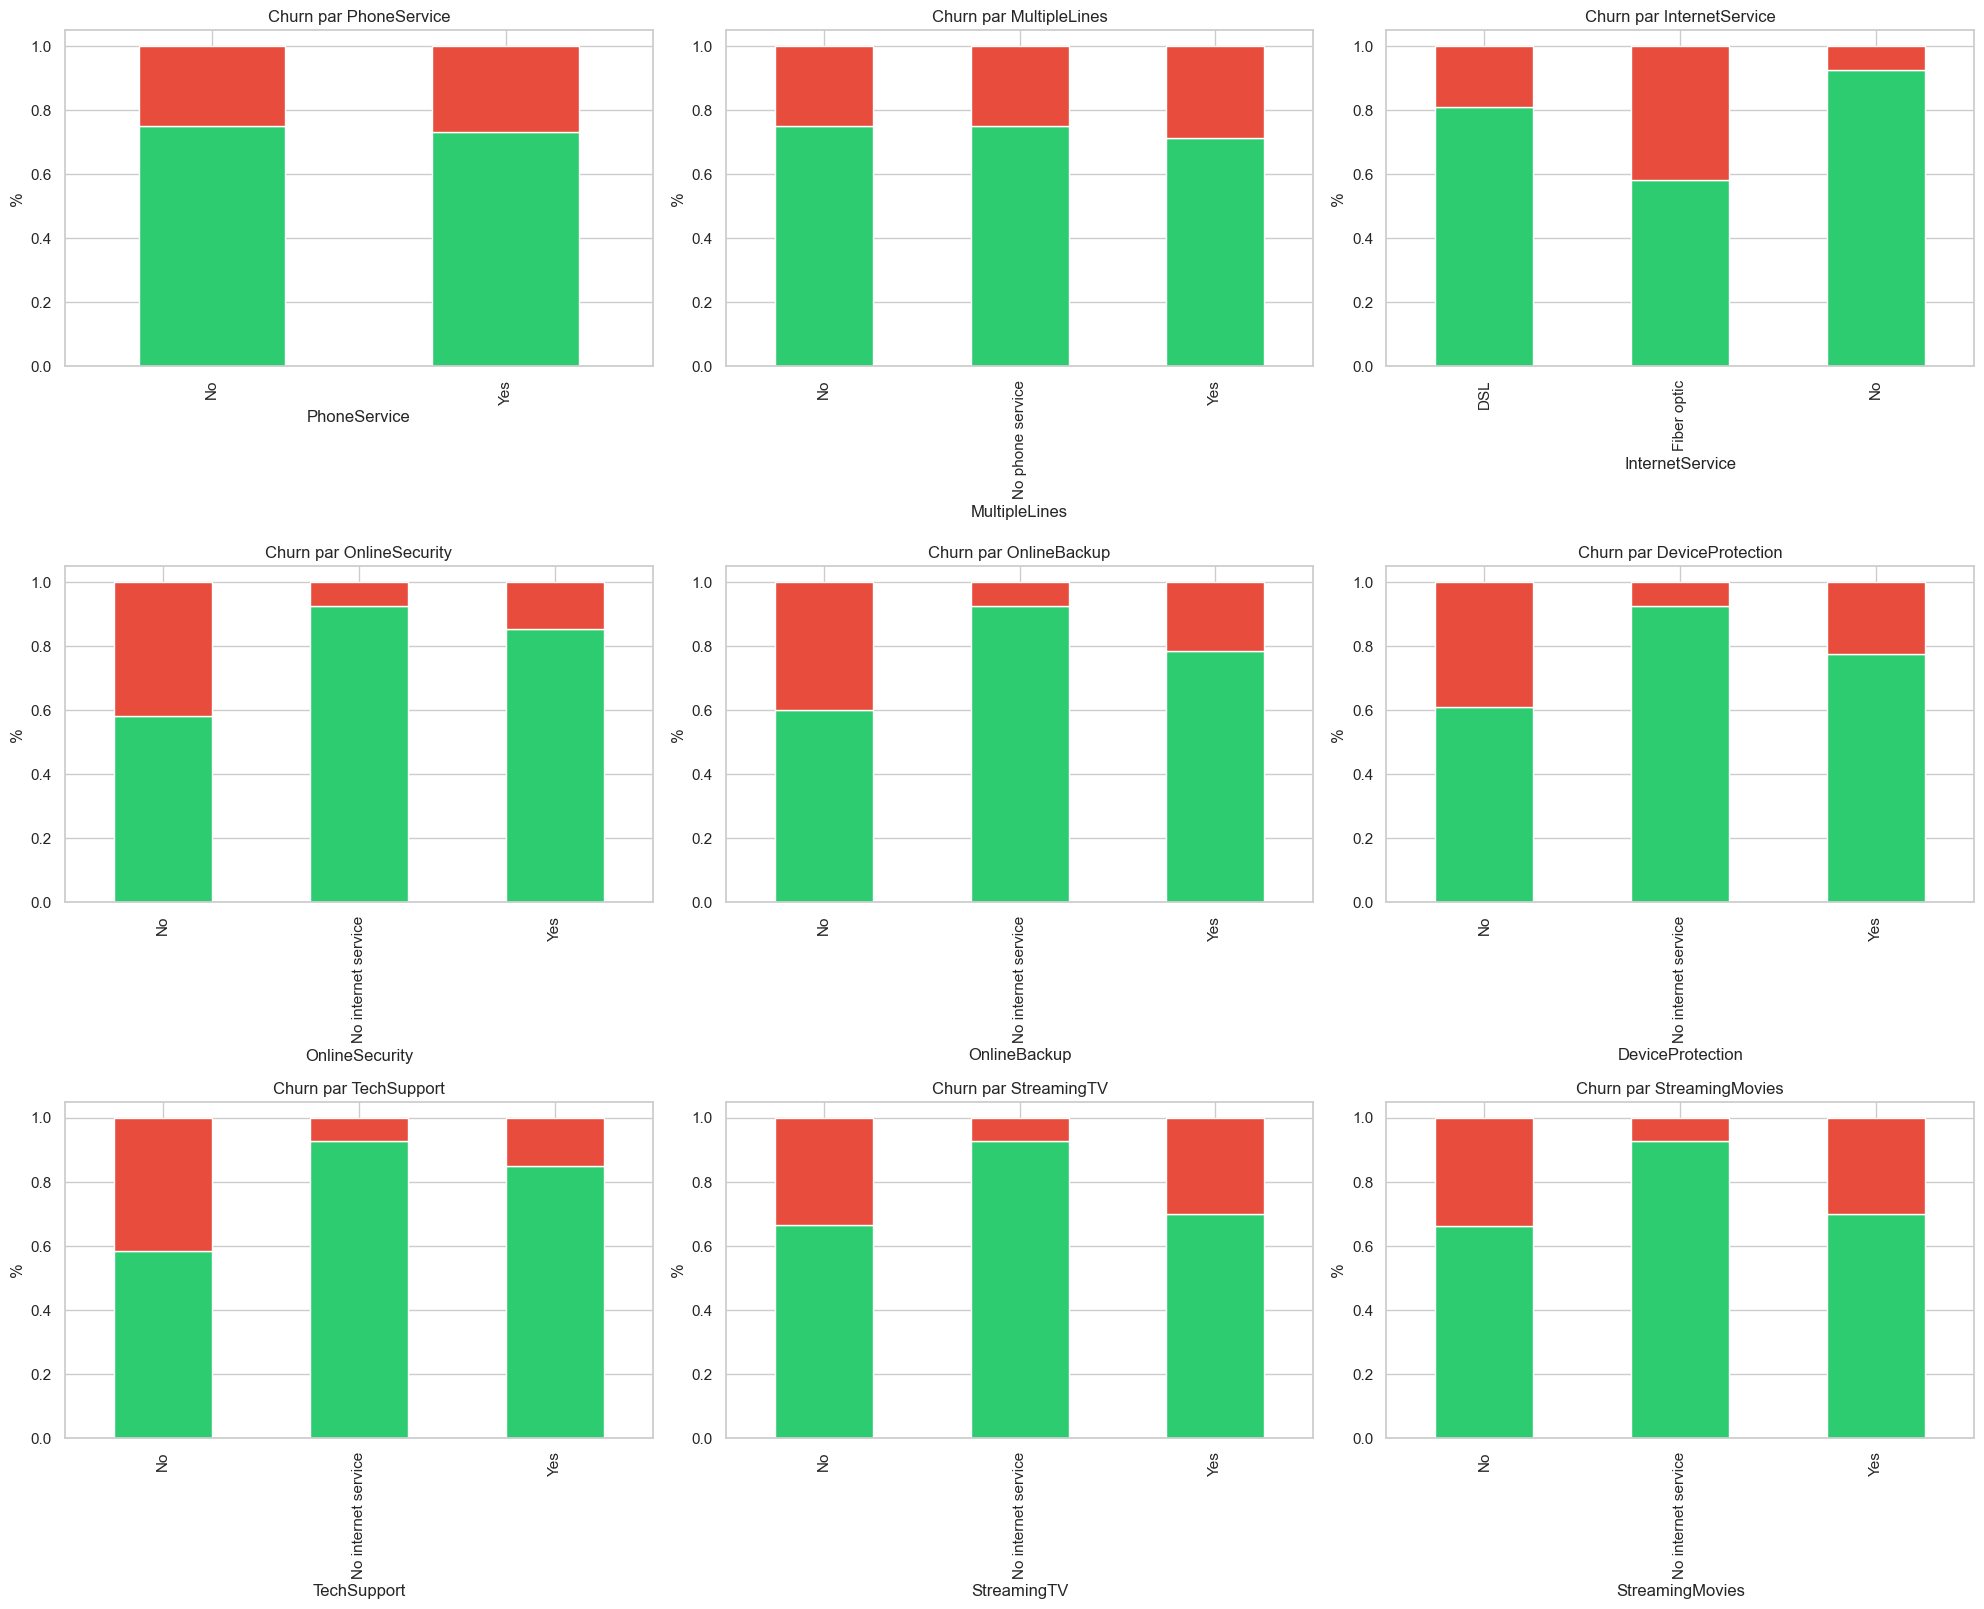

In [12]:
# Liste de tous les services additionnels
all_services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# On crée une grille dynamique (3 colonnes)
rows = (len(all_services) // 3) + 1
fig, axes = plt.subplots(rows, 3, figsize=(20, rows * 5))
axes = axes.flatten()

for i, service in enumerate(all_services):
    # Calcul des pourcentages
    df_pct = df.groupby([service, 'Churn']).size().unstack()
    df_pct = df_pct.div(df_pct.sum(axis=1), axis=0)
    
    # Plot
    df_pct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'], legend=False)
    axes[i].set_title(f'Churn par {service}')
    axes[i].set_ylabel('%')

# Supprimer les axes vides si besoin
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Interprétation Business :** L'analyse croisée des services montre que la technologie de connexion et l'accompagnement technique sont les deux piliers de la rétention. On observe un taux de churn critique chez les utilisateurs de la Fibre Optique, presque deux fois supérieur à celui du DSL, ce qui suggère une insatisfaction liée soit au prix, soit à la stabilité du réseau. Cette vulnérabilité est accentuée par l'absence de services de protection : les clients sans Support Technique ou sans Sécurité en ligne sont les plus enclins à résilier. Ces options agissent comme des facteurs de réassurance indispensables ; les intégrer d'office dans les offres Fibre pourrait constituer un levier majeur pour stabiliser ce segment de clientèle à haute valeur.

## 4. Analyse Financière Initiale

/var/folders/_m/sptr_0490fqbhk5rx47f__9w0000gn/T/ipykernel_66777/2868450169.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='MonthlyCharges_Bins', y=(df['Churn'] == 'Yes').astype(int), palette='coolwarm')


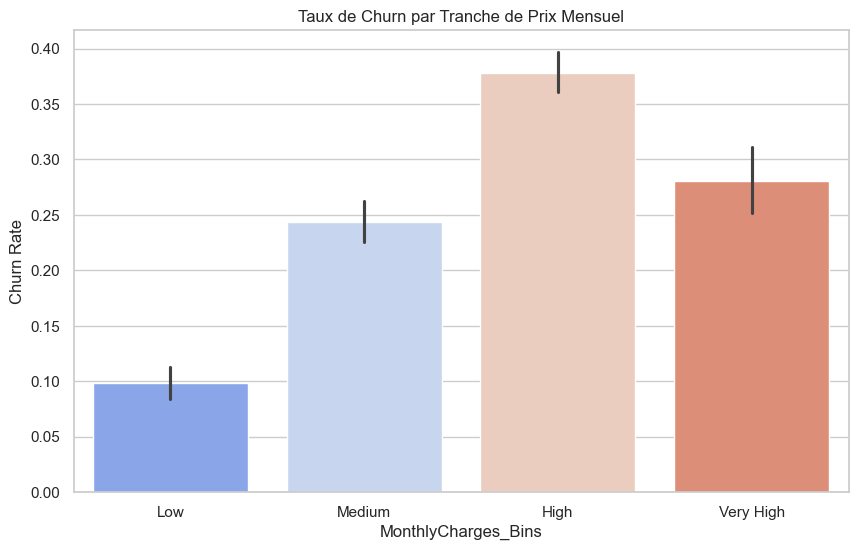

In [6]:
df['MonthlyCharges_Bins'] = pd.cut(df['MonthlyCharges'], bins=[0, 30, 70, 100, 150], labels=['Low', 'Medium', 'High', 'Very High'])

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='MonthlyCharges_Bins', y=(df['Churn'] == 'Yes').astype(int), palette='coolwarm')
plt.title('Taux de Churn par Tranche de Prix Mensuel')
plt.ylabel('Churn Rate')
plt.show()

**Interprétation Business :** L'analyse par tranches de prix révèle une corrélation directe entre le montant de la facture et la volatilité client, avec un point de rupture critique dès que les charges dépassent 70$. On observe que le taux de churn culmine sur la tranche « High », où il est presque quatre fois plus élevé que sur les petits budgets. Paradoxalement, le risque semble s'atténuer légèrement pour la catégorie « Very High » ; cela suggère que les clients premium, bien que très sollicités par la concurrence, bénéficient peut-être de services spécifiques ou de remises de fidélité qui freinent leur départ par rapport à la classe moyenne-supérieure.

## 5. Détection des anomalies et corrélations

/var/folders/_m/sptr_0490fqbhk5rx47f__9w0000gn/T/ipykernel_66777/1768027179.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_corr.select_dtypes(include=['object', 'category']).columns:


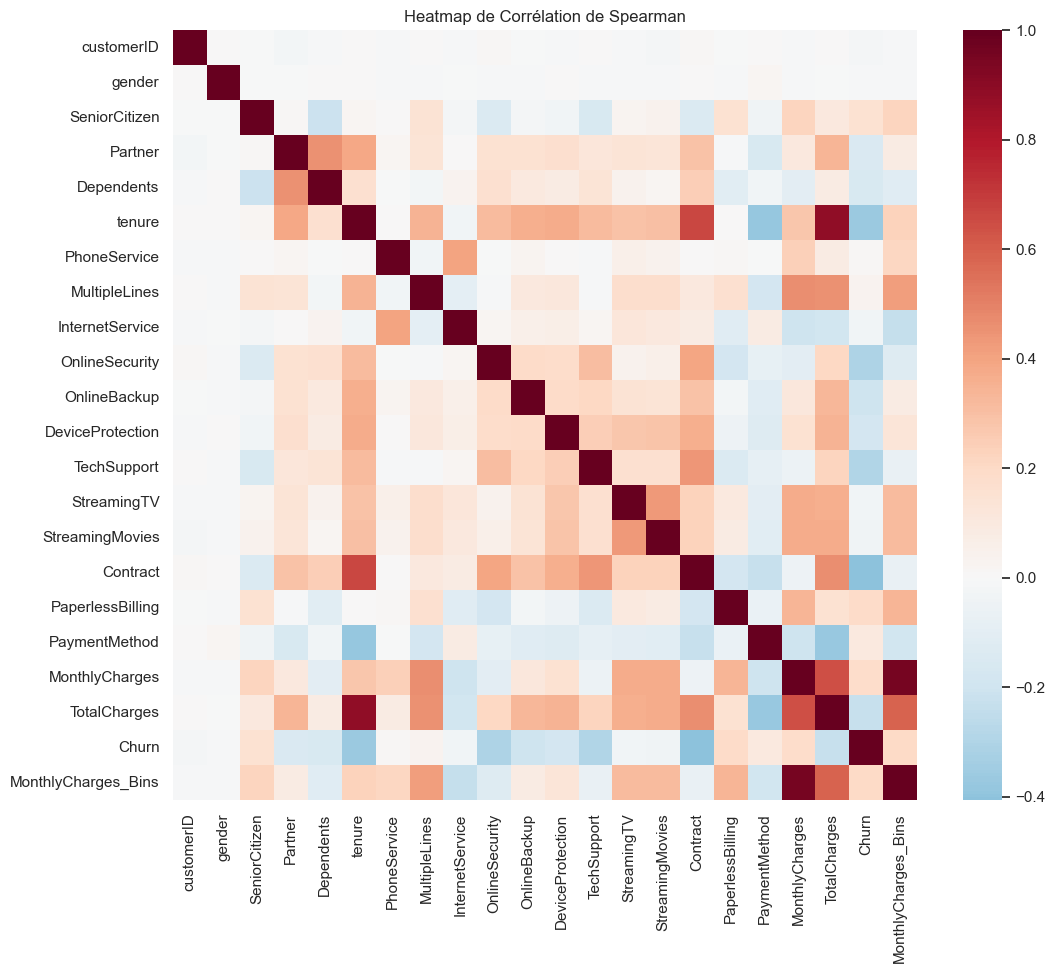

In [8]:
# Préparation pour la corrélation (encodage simple pour Spearman)
df_corr = df.copy()
df_corr['Churn'] = (df_corr['Churn'] == 'Yes').astype(int)
for col in df_corr.select_dtypes(include=['object', 'category']).columns:
    df_corr[col] = df_corr[col].astype('category').cat.codes

plt.figure(figsize=(12, 10))
corr_matrix = df_corr.corr(method='spearman')
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0)
plt.title('Heatmap de Corrélation de Spearman')
plt.show()

**Interprétation Business :** L’analyse des corrélations met en lumière deux leviers critiques : la pression tarifaire et l'ancrage temporel. On observe que le risque de départ s'intensifie mécaniquement avec la hausse des mensualités, confirmant que le prix reste le principal point de friction. À l'inverse, la longévité du client (tenure) et les contrats long terme agissent comme de véritables barrières au churn : plus un client reste, plus il se stabilise. Notez la forte colinéarité entre l’ancienneté et le chiffre d'affaires total (TotalCharges), ce qui nous poussera à ne garder que la tenure pour ne pas biaiser le modèle. Enfin, des critères comme le genre ou l'ID client n'ayant aucun impact statistique, ils seront écartés pour concentrer l'algorithme sur les variables réellement prédictives.

In [9]:
# Analyse du Churn sur les clients à forte valeur (Top 25% TotalCharges)
threshold = df['TotalCharges'].quantile(0.75)
high_value_churn = df[df['TotalCharges'] > threshold]['Churn'].value_counts(normalize=True)

print(f"Taux de churn chez les clients Premium : {high_value_churn['Yes']:.2f}%")

Taux de churn chez les clients Premium : 0.14%


/var/folders/_m/sptr_0490fqbhk5rx47f__9w0000gn/T/ipykernel_66777/333347630.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='TotalServices', y=(df['Churn'] == 'Yes').astype(int), palette='Blues_d')


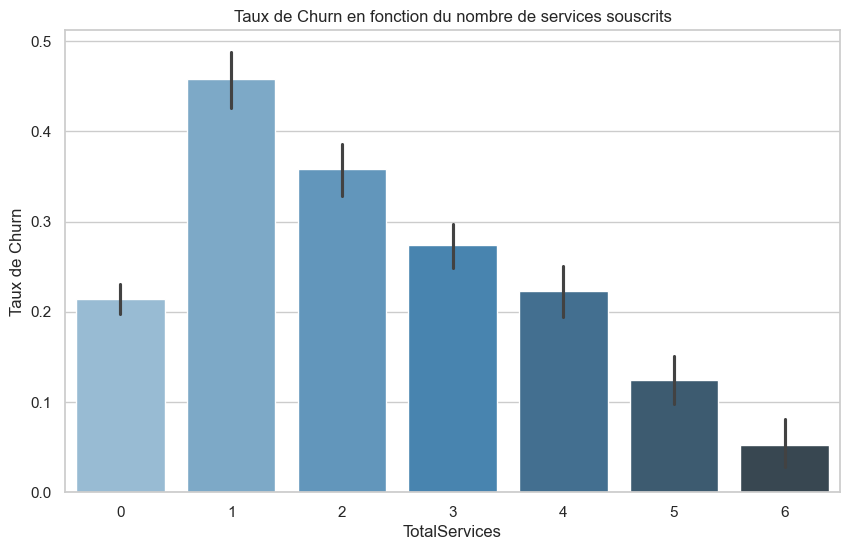

In [10]:
# On compte combien de services 'Yes' le client possède
services_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['TotalServices'] = (df[services_cols] == 'Yes').sum(axis=1)

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='TotalServices', y=(df['Churn'] == 'Yes').astype(int), palette='Blues_d')
plt.title('Taux de Churn en fonction du nombre de services souscrits')
plt.ylabel('Taux de Churn')
plt.show()

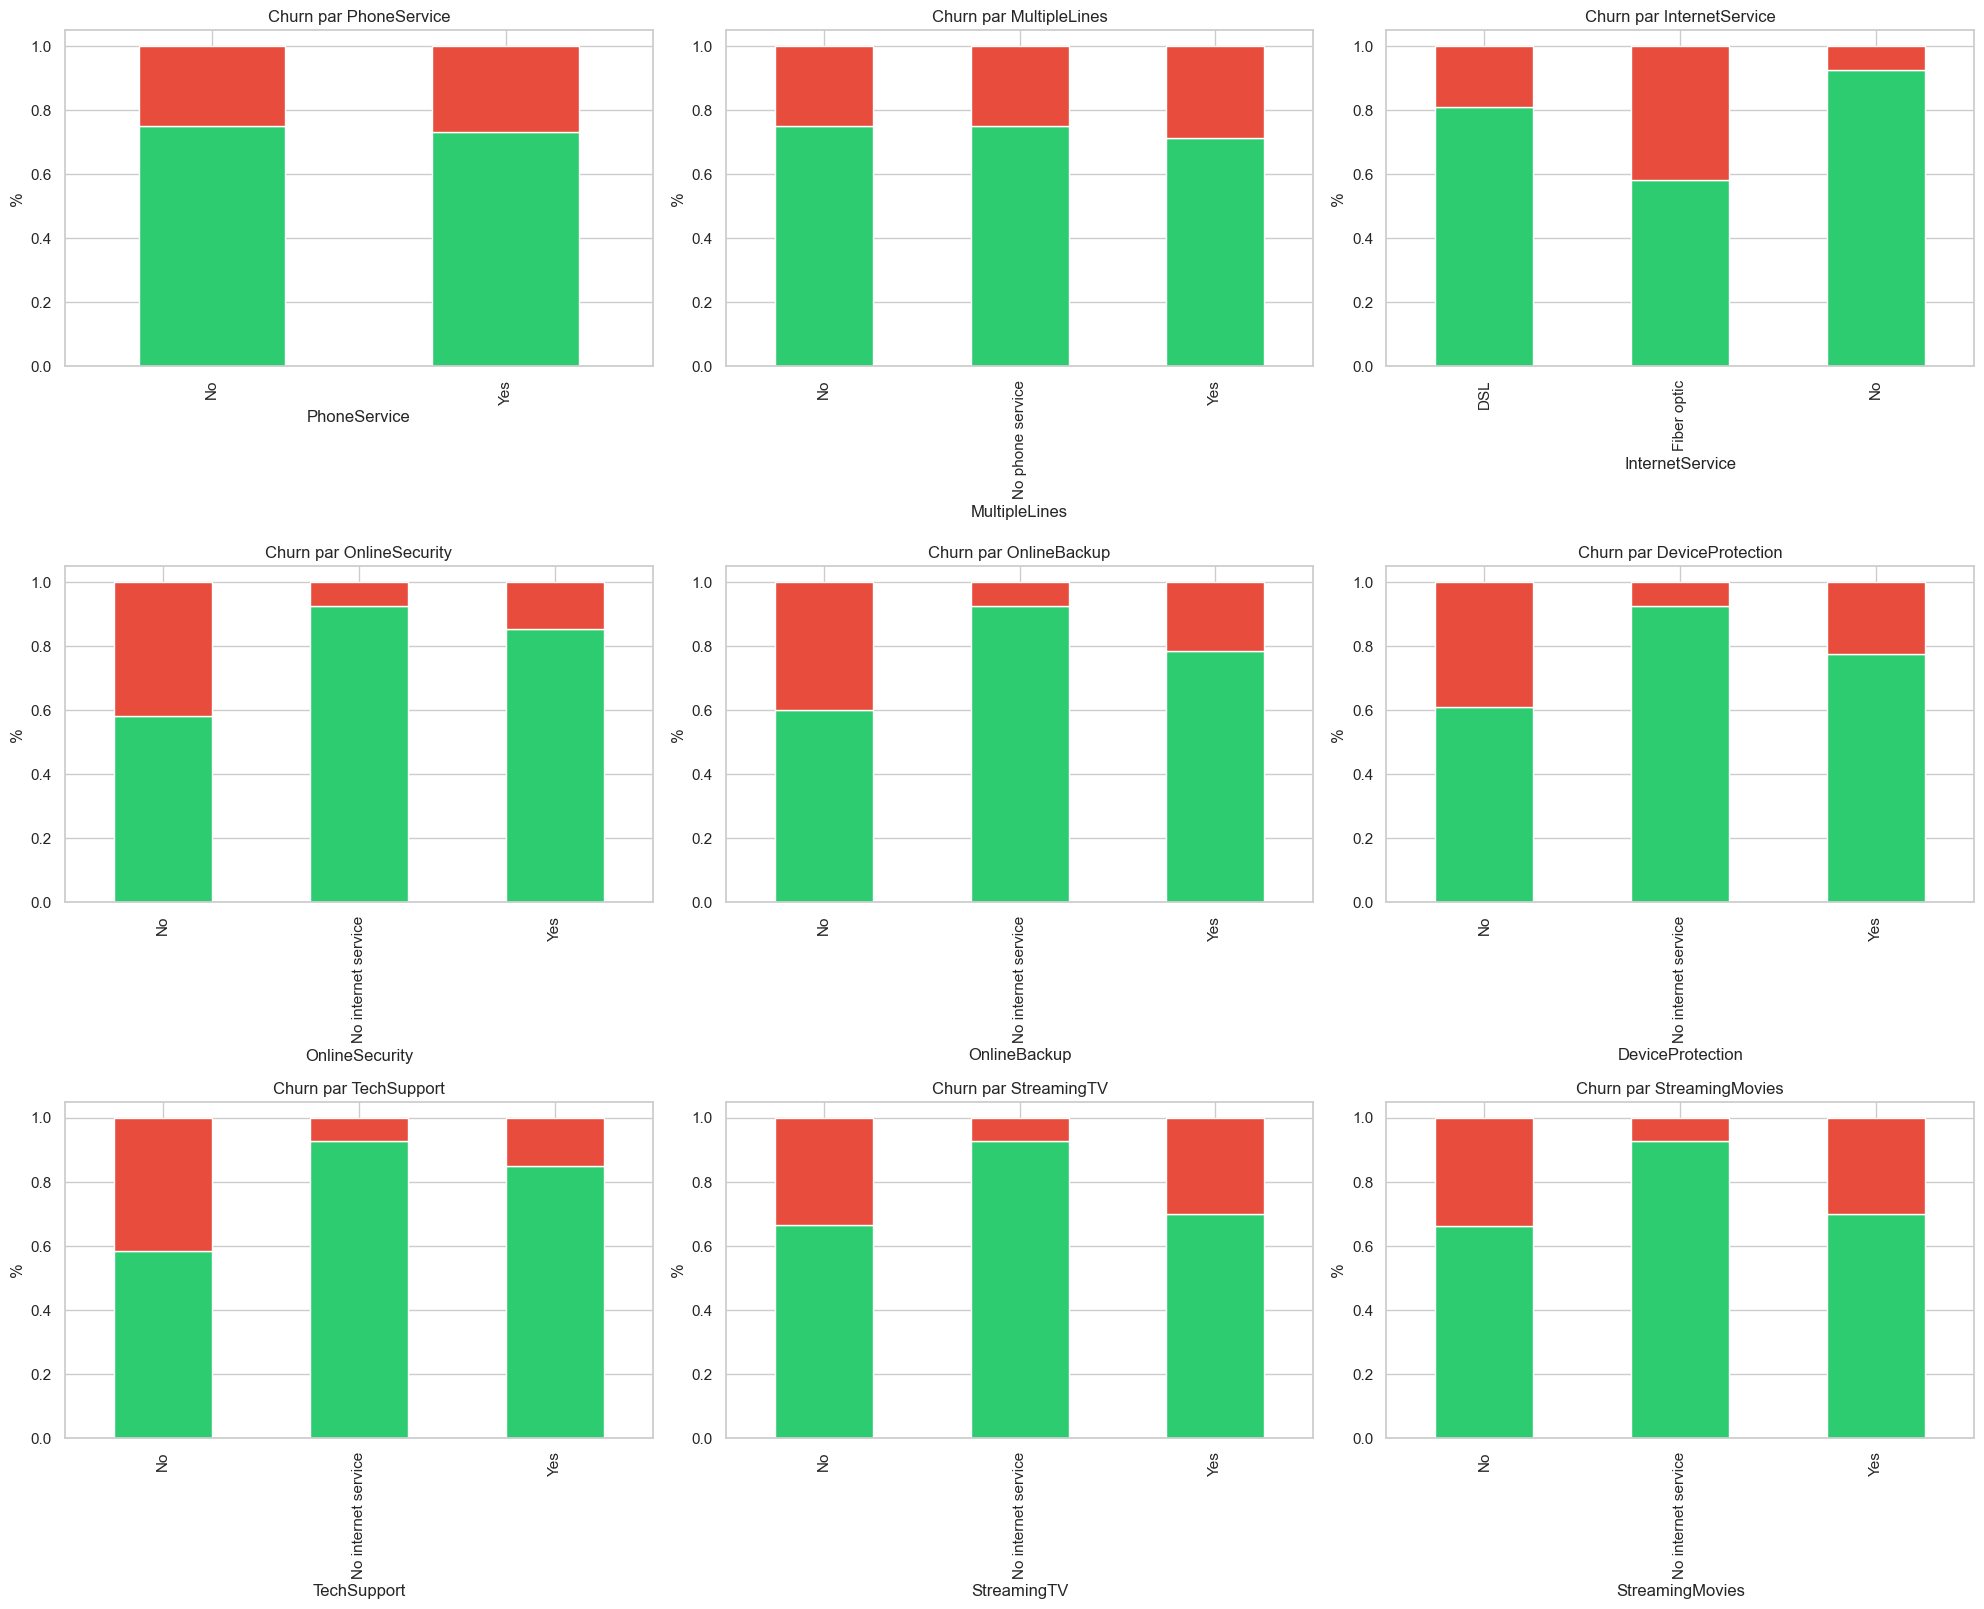